# Inverting sequences

In [1]:
import numpy as np
import tensorflow as tf

## 1.
Create a Layer class in Keras that adds positional encoding to the input sequences. The positional encoding should be based on the sine and cosine functions of different frequencies, as described below:

$$PE_{(p, 2i)} = \sin(p / 10000^{2i/d})$$
$$PE_{(p, 2i+1)} = \cos(p / 10000^{2i/d})$$

Use the  following code as a starting point:

In [2]:
class PositionalEncoding(tf.keras.layers.Layer):
    def __init__(self, max_len, d_model, **kwargs):
        super().__init__(**kwargs)
        p, i = np.meshgrid(np.arange(max_len), np.arange(d_model // 2))
        angles = p / 10000 ** (2 * i / d_model)
        pos_encoding = np.zeros((max_len, d_model))
        pos_encoding[:, 0::2] = np.sin(angles).T
        pos_encoding[:, 1::2] = np.cos(angles).T
        self.pos_encoding = tf.constant(pos_encoding[np.newaxis], dtype=tf.float32)

    def call(self, x):
        return x + self.pos_encoding[:, :tf.shape(x)[1], :]

In [3]:
pe = PositionalEncoding(max_len=100, d_model=4)
x = tf.ones((1, 10, 4))
print(pe(x))

tf.Tensor(
[[[1.         2.         1.         2.        ]
  [1.841471   1.5403023  1.0099999  1.9999499 ]
  [1.9092975  0.5838531  1.0199987  1.9998    ]
  [1.14112    0.0100075  1.0299954  1.9995501 ]
  [0.2431975  0.3463564  1.0399894  1.9992001 ]
  [0.04107571 1.2836622  1.0499792  1.9987502 ]
  [0.7205845  1.9601703  1.0599641  1.9982005 ]
  [1.6569866  1.7539022  1.0699428  1.997551  ]
  [1.9893582  0.85449994 1.0799147  1.9968017 ]
  [1.4121184  0.08886975 1.0898786  1.9959527 ]]], shape=(1, 10, 4), dtype=float32)


## 2.
Using `tf.keras.layers.Model`, create a simple model that takes sequences of shape *(batch_size, sequence_length, d_model)* as input and outputs a sequence of the same shape. It should consist of the following layers:

Tokens -> Embedding -> Self-Attention -> Residual -> Projection -> Softmax

Use an embedding dimension of 32 and a sequence length of 10.
The task of the model is to learn to reverse the letter sequences (i.e., "hello" -> "olleh").

In [4]:
# Model hyperparameters
sequence_length = 10
embedding_dim = 32

# Character-level vocabulary for lowercase letters + space.
# 0 is reserved for padding.
vocab = list("abcdefghijklmnopqrstuvwxyz ")
vocab_size = len(vocab) + 1
char_to_id = {ch: i + 1 for i, ch in enumerate(vocab)}
id_to_char = {i + 1: ch for i, ch in enumerate(vocab)}

# Tokens -> Embedding
inputs = tf.keras.Input(shape=(sequence_length,), dtype=tf.int32, name="tokens")
x = tf.keras.layers.Embedding(
    input_dim=vocab_size,
    output_dim=embedding_dim,
    name="embedding"
 )(inputs)

# Add positional information
x = PositionalEncoding(max_len=sequence_length, d_model=embedding_dim, name="positional_encoding")(x)

# Self-Attention (also return attention score matrix)
attn_layer = tf.keras.layers.MultiHeadAttention(
    num_heads=1,
    key_dim=embedding_dim // 2,
    name="self_attention"
 )
attn_out, attention_scores = attn_layer(x, x, return_attention_scores=True)

# Residual
x = tf.keras.layers.Add(name="residual")([x, attn_out])
x = tf.keras.layers.LayerNormalization(name="layer_norm")(x)

# Projection -> Softmax
logits = tf.keras.layers.Dense(vocab_size, name="projection")(x)
token_probs = tf.keras.layers.Activation("softmax", name="token_probs")(logits)

# Output both token probabilities and attention scores
model = tf.keras.Model(
    inputs=inputs,
    outputs=[token_probs, attention_scores],
    name="sequence_reverser_with_attention"
)
model.compile(
    optimizer="adam",
    loss=["sparse_categorical_crossentropy", None],
    metrics=[["accuracy"], None]
)

model.summary()

Model: "sequence_reverser_with_attention"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ tokens (InputLayer) │ (None, 10)        │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 10, 32)    │        896 │ tokens[0][0]      │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ positional_encoding │ (None, 10, 32)    │          0 │ embedding[0][0]   │
│ (PositionalEncodin… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ self_attention      │ [(None, 10, 32),  │      2,128 │ positional_encod… │
│ (MultiHeadAttentio… │ (None, 1, 10,     │            │ positional_encod… │
│                     │ 10)]              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ residual (Add)      │ (None, 10, 32)    │          0 │ positional_encod… │
│                     │                   │            │ self_attention[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_norm          │ (None, 10, 32)    │         64 │ residual[0][0]    │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ projection (Dense)  │ (None, 10, 28)    │        924 │ layer_norm[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ token_probs         │ (None, 10, 28)    │          0 │ projection[0][0]  │
│ (Activation)        │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 4,012 (15.67 KB)

 Trainable params: 4,012 (15.67 KB)

 Non-trainable params: 0 (0.00 B)

## 3.
Create a dataset of 1000 random sequences of letters and their reversed counterparts.

In [5]:
# Build a synthetic dataset of random letter sequences and reversed targets
num_samples = 1000
letters = list("abcdefghijklmnopqrstuvwxyz")

def random_sequence(seq_len=sequence_length):
    return "".join(np.random.choice(letters, size=seq_len))

def encode_text(text):
    return [char_to_id[ch] for ch in text]

def decode_ids(token_ids):
    return "".join(id_to_char.get(int(i), "") for i in token_ids if int(i) != 0)

texts = [random_sequence(sequence_length) for _ in range(num_samples)]
reversed_texts = [t[::-1] for t in texts]

X = np.array([encode_text(t) for t in texts], dtype=np.int32)
y = np.array([encode_text(t) for t in reversed_texts], dtype=np.int32)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Example input :", texts[0])
print("Example target:", reversed_texts[0])

X shape: (1000, 10)
y shape: (1000, 10)
Example input : ikcfqlfmjk
Example target: kjmflqfcki


## 4.
Train the model and evaluate its performance on the task of reversing sequences.

Validation loss: 0.0256
Validation token accuracy: 1.0000
Attention score tensor shape: (5, 1, 10, 10)
Input : mhzilchzkm
Target: mkzhclizhm
Pred  : mkzhclizhm
------------------------------
Input : mnjgegoupa
Target: apuogegjnm
Pred  : apuogegjnm
------------------------------
Input : myvipasezc
Target: czesapivym
Pred  : czesapivym
------------------------------
Input : fjuoncwafs
Target: sfawcnoujf
Pred  : sfawcnoujf
------------------------------
Input : xztowwjclg
Target: glcjwwotzx
Pred  : glcjwwotzx
------------------------------


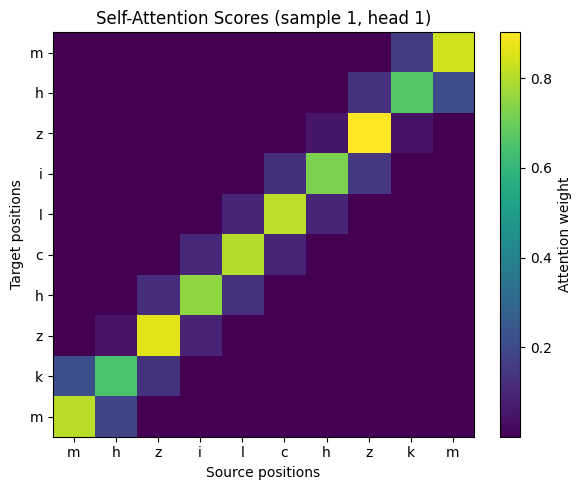

In [6]:
# Train/validation split
split_idx = int(0.8 * num_samples)
X_train, X_val = X[:split_idx], X[split_idx:]
y_train, y_val = y[:split_idx], y[split_idx:]

# Provide a dummy target for attention_scores (ignored because loss=None)
dummy_train_scores = np.zeros((X_train.shape[0], 2, sequence_length, sequence_length), dtype=np.float32)
dummy_val_scores = np.zeros((X_val.shape[0], 2, sequence_length, sequence_length), dtype=np.float32)

history = model.fit(
    X_train,
    [y_train, dummy_train_scores],
    validation_data=(X_val, [y_val, dummy_val_scores]),
    epochs=30,
    batch_size=32,
    verbose=0
)

eval_results = model.evaluate(
    X_val,
    [y_val, dummy_val_scores],
    verbose=0,
    return_dict=True
)
print(f"Validation loss: {eval_results['loss']:.4f}")
print(f"Validation token accuracy: {eval_results['token_probs_accuracy']:.4f}")

# Show a few predictions and the attention score shape
pred_token_probs, pred_attention_scores = model.predict(X_val[:5], verbose=0)
pred_ids = np.argmax(pred_token_probs, axis=-1)
print("Attention score tensor shape:", pred_attention_scores.shape)

for i in range(5):
    src = decode_ids(X_val[i])
    tgt = decode_ids(y_val[i])
    pred = decode_ids(pred_ids[i])
    print(f"Input : {src}")
    print(f"Target: {tgt}")
    print(f"Pred  : {pred}")
    print("-" * 30)

# Visualize attention scores for sample 1, head 1
import matplotlib.pyplot as plt

sample_idx = 0
head_idx = 0
attn = pred_attention_scores[sample_idx, head_idx]  # (target_len, source_len)
src_text = decode_ids(X_val[sample_idx])

plt.figure(figsize=(6, 5))
plt.imshow(attn, cmap="viridis", aspect="auto")
plt.title("Self-Attention Scores (sample 1, head 1)")
plt.xlabel("Source positions")
plt.ylabel("Target positions")
plt.colorbar(label="Attention weight")
plt.xticks(range(sequence_length), list(src_text))
plt.yticks(range(sequence_length), list(src_text))
plt.tight_layout()
plt.show()